In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import time
from tqdm import tqdm
import random
import gc

print(f"TensorFlow Version: {tf.__version__}")

# OPTIMIZACIÓN 1: Habilitar Mixed Precision (2-3x más rápido)
print("\nHabilitando Mixed Precision Training...")
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"Política de Mixed Precision: {policy. name}")
print("Compute dtype: %s" % policy.compute_dtype)
print("Variable dtype: %s" % policy. variable_dtype)

# OPTIMIZACIÓN 2: Configurar GPU con XLA
print("\nVerificando GPU...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPUs encontradas: {gpus}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    # Habilitar XLA (20-30% más rápido)
    tf.config.optimizer. set_jit(True)
    print("XLA JIT Compilation: HABILITADO")
else:
    print("No se encontraron GPUs.  Usando CPU.")

TensorFlow Version: 2.19.0

Habilitando Mixed Precision Training...
Política de Mixed Precision: mixed_float16
Compute dtype: float16
Variable dtype: float32

Verificando GPU...
GPUs encontradas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
XLA JIT Compilation: HABILITADO


In [ ]:
# Descargar datos
!gdown --id 1SSrcU-0Ph-ONr5r0qpr9V5ssF-OIVN2r
!unzip -q Dataset_Evolutivo_Simulado.zip
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1SSrcU-0Ph-ONr5r0qpr9V5ssF-OIVN2r
From (redirected): https://drive.google.com/uc?id=1SSrcU-0Ph-ONr5r0qpr9V5ssF-OIVN2r&confirm=t&uuid=a9acf43a-1469-45c9-bf34-55e6914bc464
To: /content/Dataset_Evolutivo_Simulado.zip
100% 627M/627M [00:08<00:00, 71.7MB/s]
Mounted at /content/drive


In [ ]:
print("\n" + "="*80)
print("PASO 1: Definiendo parámetros globales OPTIMIZADOS")
print("="*80)

# Rutas
PATH = 'Dataset_Evolutivo_Simulado/'
TRAIN_A_DIR = os.path.join(PATH, 'train_A')
TRAIN_B_DIR = os.path.join(PATH, 'train_B')

OUTPUT_IMG_DIR = 'Resultados_DenseNet_FT'
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)

checkpoint_dir = '/content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/DenseNet121_Checkpoint'
os.makedirs(checkpoint_dir, exist_ok=True)

model_save_path = os.path.join('/content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/DenseNet121_Checkpoint', 'densenet_generator_final.keras')

# OPTIMIZACIÓN 3: Parámetros ajustados para mejor rendimiento
BUFFER_SIZE = 1000        # Aumentado de 400 a 1000
BATCH_SIZE = 16           # Aumentado de 8 a 16 (aprovecha mixed precision)
IMG_WIDTH = 256
IMG_HEIGHT = 256
EPOCHS = 100
LAMBDA = 100

# Parámetros de Fine-Tuning
LR_WARMUP = 2e-4
LR_FINETUNE = 1e-5
FT_EPOCH = 10
CHECKPOINT_INTERVAL = 20

IMG_GEN_INTERVAL = 5

print(f"Configuración cargada (OPTIMIZADA)")
print(f"  - Épocas totales: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE} (aumentado para mixed precision)")
print(f"  - Buffer size: {BUFFER_SIZE} (aumentado)")
print(f"  - Fine-tuning inicia en época: {FT_EPOCH}")
print(f"  - LR Warmup: {LR_WARMUP:.0e}, LR Fine-tuning: {LR_FINETUNE:.0e}")
print(f"  - Checkpoints cada: {CHECKPOINT_INTERVAL} épocas")
print(f"  - Imágenes de prueba cada: {IMG_GEN_INTERVAL} épocas")


PASO 1: Definiendo parámetros globales OPTIMIZADOS
Configuración cargada (OPTIMIZADA)
  - Épocas totales: 100
  - Batch size: 16 (aumentado para mixed precision)
  - Buffer size: 1000 (aumentado)
  - Fine-tuning inicia en época: 10
  - LR Warmup: 2e-04, LR Fine-tuning: 1e-05
  - Checkpoints cada: 20 épocas
  - Imágenes de prueba cada: 5 épocas


In [ ]:
print("\n" + "="*80)
print("PASO 2: Definiendo funciones de preprocesamiento")
print("="*80)

def load_image(image_file):
    """Carga un par de imágenes (T0 y T1)"""
    real_image_file = tf.strings.regex_replace(image_file, "train_A", "train_B")

    input_image = tf.io.read_file(image_file)
    input_image = tf.io.decode_jpeg(input_image, channels=3)

    real_image = tf.io.read_file(real_image_file)
    real_image = tf.io.decode_jpeg(real_image, channels=3)

    input_image = tf.cast(input_image, tf.float32)
    real_image = tf.cast(real_image, tf.float32)

    return input_image, real_image

def resize(input_image, real_image, height, width):
    """Redimensiona imágenes"""
    input_image = tf.image.resize(input_image, [height, width],
                                  method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    real_image = tf.image.resize(real_image, [height, width],
                                 method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    return input_image, real_image

def random_crop(input_image, real_image):
    """Recorte aleatorio para data augmentation"""
    stacked_image = tf.stack([input_image, real_image], axis=0)
    cropped_image = tf.image.random_crop(stacked_image, size=[2, IMG_HEIGHT, IMG_WIDTH, 3])
    return cropped_image[0], cropped_image[1]

def normalize(input_image, real_image):
    """Normaliza imágenes al rango [-1, 1]"""
    input_image = (input_image / 127.5) - 1
    real_image = (real_image / 127.5) - 1
    return input_image, real_image

@tf.function()
def random_jitter(input_image, real_image):
    """Data augmentation estándar de Pix2Pix"""
    input_image, real_image = resize(input_image, real_image, 286, 286)
    input_image, real_image = random_crop(input_image, real_image)

    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        real_image = tf.image.flip_left_right(real_image)

    return input_image, real_image

def load_image_train(image_file):
    """Pipeline para imágenes de entrenamiento"""
    input_image, real_image = load_image(image_file)
    input_image, real_image = random_jitter(input_image, real_image)
    input_image, real_image = normalize(input_image, real_image)
    return input_image, real_image

def load_image_test(image_file):
    """Pipeline para imágenes de prueba"""
    input_image, real_image = load_image(image_file)
    input_image, real_image = resize(input_image, real_image, IMG_HEIGHT, IMG_WIDTH)
    input_image, real_image = normalize(input_image, real_image)
    return input_image, real_image

print("Funciones de preprocesamiento definidas")


PASO 2: Definiendo funciones de preprocesamiento
Funciones de preprocesamiento definidas


In [ ]:
print("\n" + "="*80)
print("PASO 3: Creando pipeline de tf.data OPTIMIZADO")
print("="*80)

train_files_pattern = os.path.join(TRAIN_A_DIR, '*.jpg')
train_files = glob.glob(train_files_pattern)
num_train_files = len(train_files)

if num_train_files == 0:
    raise ValueError(f"¡ERROR! No se encontraron imágenes en: {train_files_pattern}")

print(f"Total de pares de entrenamiento encontrados: {num_train_files}")

# OPTIMIZACIÓN 5: Pipeline de datos más eficiente
train_dataset = tf.data.Dataset.list_files(train_files_pattern, shuffle=True)
train_dataset = train_dataset.map(
    load_image_train,
    num_parallel_calls=tf.data.AUTOTUNE,
    deterministic=False  # Más rápido
)
train_dataset = train_dataset. cache()  # Cache en memoria
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE, drop_remainder=True)
train_dataset = train_dataset.repeat()  # Repetir indefinidamente
train_dataset = train_dataset.prefetch(buffer_size=tf.data. AUTOTUNE)

# Dataset de prueba
test_files_to_use = random.sample(train_files, min(10, num_train_files))
test_dataset = tf.data. Dataset.from_tensor_slices(test_files_to_use)
test_dataset = test_dataset.map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(buffer_size=tf. data.AUTOTUNE)

steps_per_epoch = num_train_files // BATCH_SIZE

print(f"Pipeline de datos creado exitosamente")
print(f"Steps por época: {steps_per_epoch}")
print(f"Dataset cacheado en memoria para máximo rendimiento")


PASO 3: Creando pipeline de tf.data OPTIMIZADO
Total de pares de entrenamiento encontrados: 1863
Pipeline de datos creado exitosamente
Steps por época: 116
Dataset cacheado en memoria para máximo rendimiento


In [ ]:
print("\n" + "="*80)
print("PASO 4: Definiendo bloques de arquitectura")
print("="*80)

def downsample_pix2pix(filters, size, apply_batchnorm=True):
    """Bloque de downsampling para el discriminador"""
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result. add(layers.LeakyReLU())
    return result

def upsample_pix2pix(filters, size, apply_dropout=False):
    """Bloque de upsampling para el decoder del generador"""
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2, padding='same',
                                      kernel_initializer=initializer, use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers. ReLU())
    return result

print("Bloques de arquitectura definidos")


PASO 4: Definiendo bloques de arquitectura
Bloques de arquitectura definidos


In [ ]:
print("\n" + "="*80)
print("PASO 5: Construyendo Generador U-Net con DenseNet121")
print("="*80)

def build_generator():
    """
    Generador U-Net con DenseNet121 como encoder (Transfer Learning)
    OPTIMIZADO para Mixed Precision
    """
    inputs = layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, 3])

    # --- ENCODER: DenseNet121 Pre-entrenado ---
    base_model = DenseNet121(
        input_shape=[IMG_WIDTH, IMG_HEIGHT, 3],
        include_top=False,
        weights='imagenet'
    )

    # Capas para skip connections
    layer_names = [
        'conv1_relu',      # 128x128
        'pool2_conv',      # 64x64
        'pool3_conv',      # 32x32
        'pool4_conv',      # 16x16
    ]

    layer_outputs = [base_model.get_layer(name).output for name in layer_names]
    layer_outputs. append(base_model.output)  # Bottleneck 8x8

    encoder = Model(
        inputs=base_model.input,
        outputs=layer_outputs,
        name="densenet_encoder"
    )

    # Congelar encoder inicialmente
    encoder.trainable = False

    # Obtener skip connections
    skips = encoder(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])

    # --- DECODER ---
    up_stack = [
        upsample_pix2pix(512, 4, apply_dropout=True),
        upsample_pix2pix(256, 4, apply_dropout=True),
        upsample_pix2pix(128, 4, apply_dropout=True),
        upsample_pix2pix(64, 4),
    ]

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers. Concatenate()([x, skip])

    # Capa final
    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(
        3, 4, strides=2, padding='same',
        kernel_initializer=initializer,
        activation='tanh',
        dtype='float32'  # IMPORTANTE: Salida en float32 para estabilidad
    )
    x = last(x)

    return Model(inputs=inputs, outputs=x, name="DenseNet_Generator")

generator = build_generator()
print("Generador construido")
print(f"Variables entrenables iniciales: {len(generator.trainable_variables)}")


PASO 5: Construyendo Generador U-Net con DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Generador construido
Variables entrenables iniciales: 14


In [ ]:
print("\n" + "="*80)
print("PASO 6: Construyendo Discriminador PatchGAN")
print("="*80)

def build_discriminator():
    """
    Discriminador PatchGAN (clasifica patches de 30x30)
    """
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, 3], name='input_image')
    tar = layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, 3], name='target_image')

    x = layers.concatenate([inp, tar])  # (bs, 256, 256, 6)

    down1 = downsample_pix2pix(64, 4, False)(x)   # (bs, 128, 128, 64)
    down2 = downsample_pix2pix(128, 4)(down1)     # (bs, 64, 64, 128)
    down3 = downsample_pix2pix(256, 4)(down2)     # (bs, 32, 32, 256)

    zero_pad1 = layers.ZeroPadding2D()(down3)     # (bs, 34, 34, 256)
    conv = layers.Conv2D(512, 4, strides=1,
                         kernel_initializer=initializer,
                         use_bias=False)(zero_pad1)  # (bs, 31, 31, 512)

    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)

    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)  # (bs, 33, 33, 512)
    last = layers.Conv2D(1, 4, strides=1,
                         kernel_initializer=initializer)(zero_pad2)  # (bs, 30, 30, 1)

    return Model(inputs=[inp, tar], outputs=last, name="PatchGAN_Discriminator")

discriminator = build_discriminator()
print("Discriminador construido")


PASO 6: Construyendo Discriminador PatchGAN
Discriminador construido


In [ ]:
print("\n" + "="*80)
print("PASO 7: Definiendo funciones de pérdida")
print("="*80)

bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(disc_real_output, disc_generated_output):
    """
    Pérdida del discriminador con label smoothing
    """
    real_loss = bce(tf.ones_like(disc_real_output) * 0.9, disc_real_output)
    generated_loss = bce(tf.zeros_like(disc_generated_output), disc_generated_output)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss

def generator_loss(disc_generated_output, gen_output, target):
    """
    Pérdida del generador: GAN loss + L1 loss
    """
    gan_loss = bce(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)
    return total_gen_loss, gan_loss, l1_loss

print("Funciones de pérdida definidas")


PASO 7: Definiendo funciones de pérdida
Funciones de pérdida definidas


In [ ]:
print("\n" + "="*80)
print("PASO 8: Configurando optimizadores y checkpoints")
print("="*80)

# Optimizadores iniciales
generator_optimizer = tf.keras.optimizers.Adam(LR_WARMUP, beta_1=0.5)
discriminator_optimizer = tf. keras.optimizers.Adam(LR_WARMUP, beta_1=0.5)

# Checkpoint
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator
)

print("Optimizadores y checkpoint configurados")


PASO 8: Configurando optimizadores y checkpoints
Optimizadores y checkpoint configurados


In [ ]:
print("\n" + "="*80)
print("PASO 9: Intentando restaurar checkpoint previo")
print("="*80)

start_epoch = 0
latest_ckpt = tf.train.latest_checkpoint(checkpoint_dir)

if latest_ckpt:
    try:
        status = checkpoint.restore(latest_ckpt)
        status.expect_partial()

        ckpt_number = int(latest_ckpt.split('-')[-1])
        start_epoch = ckpt_number * CHECKPOINT_INTERVAL

        print(f" Checkpoint restaurado: {os.path.basename(latest_ckpt)}")
        print(f"  - Reanudando desde época: {start_epoch}")

        # Si estamos en fase de fine-tuning
        if start_epoch >= FT_EPOCH:
            print(f"  - Aplicando estado de fine-tuning...")

            encoder_layer = generator.get_layer("densenet_encoder")
            encoder_layer.trainable = True

            generator_optimizer = tf.keras.optimizers.Adam(LR_FINETUNE, beta_1=0.5)
            discriminator_optimizer = tf.keras.optimizers.Adam(LR_FINETUNE, beta_1=0.5)

            generator_optimizer.build(generator.trainable_variables)
            discriminator_optimizer. build(discriminator.trainable_variables)

            checkpoint = tf.train.Checkpoint(
                generator_optimizer=generator_optimizer,
                discriminator_optimizer=discriminator_optimizer,
                generator=generator,
                discriminator=discriminator
            )

            try:
                status = checkpoint.restore(latest_ckpt)
                status.expect_partial()
            except:
                print("    (Estado del optimizador no restaurado - normal)")

            print(f"    Encoder descongelado, LR: {LR_FINETUNE:.0e}")

    except Exception as e:
        print(f"✗ Error al restaurar: {e}")
        print("  Iniciando desde época 0")
        start_epoch = 0
else:
    print("○ No hay checkpoint previo")
    print("  Iniciando desde época 0")


PASO 9: Intentando restaurar checkpoint previo
○ No hay checkpoint previo
  Iniciando desde época 0


In [ ]:
def generate_images(model, test_input, tar, epoch, save_dir):
    """
    Genera y guarda imágenes de comparación
    OPTIMIZADO: Menos operaciones, más eficiente
    """
    # Solo generar para el primer batch
    test_input = test_input[:4]
    tar = tar[:4]

    prediction = model(test_input, training=False)

    plt.figure(figsize=(15, 5))

    display_list = [test_input[0], tar[0], prediction[0]]
    title = ['Input T0', 'Ground Truth T1', 'Predicted T1']

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i])
        # Desnormalizar de [-1, 1] a [0, 1]
        plt. imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'epoch_{epoch:03d}.png'),
                dpi=100, bbox_inches='tight')
    plt.close()

    # IMPORTANTE: Limpiar memoria
    del prediction
    gc.collect()

print("Función generate_images definida")

Función generate_images definida


In [ ]:
@tf.function(jit_compile=True)  # OPTIMIZACIÓN: XLA compilation
def train_step(input_image, target):
    """
    Paso de entrenamiento OPTIMIZADO con Mixed Precision
    Compatible con TensorFlow 2.19 y Keras 3.10
    """
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Forward pass
        gen_output = generator(input_image, training=True)

        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        # Calcular pérdidas
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(
            disc_generated_output, gen_output, target
        )
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)


    gen_gradients = gen_tape.gradient(
        gen_total_loss, generator.trainable_variables
    )
    disc_gradients = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return disc_loss, gen_total_loss, gen_gan_loss, gen_l1_loss

print("Train step optimizado definido (compatible con TensorFlow 2.19/Keras 3.10)")

Train step optimizado definido (compatible con TensorFlow 2.19/Keras 3.10)


In [ ]:
def train(dataset, epochs):
    """
    Bucle de entrenamiento OPTIMIZADO
    """
    global generator_optimizer, discriminator_optimizer, checkpoint

    print("\n" + "="*80)
    print("INICIANDO ENTRENAMIENTO OPTIMIZADO")
    print("="*80)

    # Obtener batch de prueba
    test_batch = next(iter(test_dataset))

    for epoch in range(start_epoch, epochs):
        start_time = time.time()

        # ACTIVAR FINE-TUNING
        if epoch == FT_EPOCH:
            print("\n" + "="*80)
            print(f" ACTIVANDO FINE-TUNING EN EPOCA {epoch + 1}")
            print("="*80)

            encoder_layer = generator.get_layer("densenet_encoder")
            encoder_layer.trainable = True
            print(f" Encoder descongelado")

            generator_optimizer = tf.keras. optimizers.Adam(LR_FINETUNE, beta_1=0.5)
            discriminator_optimizer = tf.keras. optimizers.Adam(LR_FINETUNE, beta_1=0.5)

            generator_optimizer.build(generator.trainable_variables)
            discriminator_optimizer.build(discriminator. trainable_variables)
            print(f" Optimizadores reconstruidos ({len(generator. trainable_variables)} vars)")

            checkpoint = tf.train.Checkpoint(
                generator_optimizer=generator_optimizer,
                discriminator_optimizer=discriminator_optimizer,
                generator=generator,
                discriminator=discriminator
            )
            print(f" LR actualizado: {LR_FINETUNE:.0e}")

            # Forzar recompilación
            train_step. get_concrete_function(
                tf.TensorSpec(shape=[None, IMG_HEIGHT, IMG_WIDTH, 3], dtype=tf.float32),
                tf.TensorSpec(shape=[None, IMG_HEIGHT, IMG_WIDTH, 3], dtype=tf.float32)
            )
            print(" Grafo recompilado")
            print("="*80 + "\n")

        # GENERAR IMAGEN (menos frecuente)
        if (epoch + 1) % IMG_GEN_INTERVAL == 0 or epoch == 0:
            print(f"Generando imagen de muestra (Epoca {epoch + 1})...")
            generate_images(generator, test_batch[0], test_batch[1],
                          epoch + 1, OUTPUT_IMG_DIR)

        print(f"\nEpoca {epoch + 1}/{epochs}")

        # Métricas
        epoch_disc_loss = []
        epoch_gen_total_loss = []
        epoch_gen_gan_loss = []
        epoch_gen_l1_loss = []

        # Barra de progreso
        pbar = tqdm(
            total=steps_per_epoch,
            desc=f"Epoca {epoch + 1}",
            unit="batch",
            ncols=100
        )

        # OPTIMIZACIÓN: Usar take() para limitar steps
        for step, (input_image, target) in enumerate(dataset. take(steps_per_epoch)):
            disc_loss, gen_total_loss, gen_gan_loss, gen_l1_loss = train_step(
                input_image, target
            )

            # Acumular pérdidas
            epoch_disc_loss.append(float(disc_loss))
            epoch_gen_total_loss.append(float(gen_total_loss))
            epoch_gen_gan_loss.append(float(gen_gan_loss))
            epoch_gen_l1_loss. append(float(gen_l1_loss))

            # Actualizar progreso
            if step % 5 == 0:
                avg_disc = np.mean(epoch_disc_loss[-20:])
                avg_gen = np.mean(epoch_gen_total_loss[-20:])
                avg_l1 = np.mean(epoch_gen_l1_loss[-20:])
                pbar.set_postfix_str(
                    f"D:{avg_disc:.2f} G:{avg_gen:.2f} L1:{avg_l1:.2f}"
                )
            pbar.update(1)

        pbar.close()

        # OPTIMIZACIÓN: Limpiar memoria cada época
        if (epoch + 1) % 5 == 0:
            gc.collect()
            tf.keras.backend.clear_session()

        # Resumen
        elapsed = time.time() - start_time
        avg_disc = np.mean(epoch_disc_loss)
        avg_gen_total = np.mean(epoch_gen_total_loss)
        avg_gen_gan = np. mean(epoch_gen_gan_loss)
        avg_gen_l1 = np.mean(epoch_gen_l1_loss)

        print(f"\n Resumen Epoca {epoch + 1}/{epochs}")
        print(f"  Tiempo: {elapsed:.1f}s ({elapsed/60:.1f} min)")
        print(f" Pérdidas:")
        print(f"   Discriminador: {avg_disc:.4f}")
        print(f"   Generador Total: {avg_gen_total:.4f}")
        print(f"   - GAN: {avg_gen_gan:.4f}")
        print(f"   - L1:  {avg_gen_l1:.4f} (x{LAMBDA})")
        print(f" LR: {float(generator_optimizer.learning_rate):.0e}")

        # Diagnóstico
        if avg_disc > 5.0:
            print("  Discriminador muy fuerte")
        elif avg_disc < 0.1:
            print("  Discriminador muy débil")

        # GUARDAR CHECKPOINT
        if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
            ckpt_prefix = os.path.join(
                checkpoint_dir,
                f"ckpt-{(epoch + 1) // CHECKPOINT_INTERVAL}"
            )
            checkpoint.save(file_prefix=ckpt_prefix)
            print(f" Checkpoint guardado: {os.path.basename(ckpt_prefix)}")

    print("\n" + "="*80)
    print(" ENTRENAMIENTO COMPLETADO")
    print("="*80)

    # Imagen final
    generate_images(generator, test_batch[0], test_batch[1],
                   epochs, OUTPUT_IMG_DIR)

    # Guardar modelo
    generator.save(model_save_path)
    print(f"Modelo guardado: {model_save_path}")

print("Función train() definida")

Función train() definida


In [ ]:
train(train_dataset, EPOCHS)
print("\n ¡Entrenamiento finalizado exitosamente!")


INICIANDO ENTRENAMIENTO OPTIMIZADO
Generando imagen de muestra (Epoca 1)...

Epoca 1/100


Epoca 1: 100%|█████████████████████████| 116/116 [00:33<00:00,  3.51batch/s, D:0.72 G:25.02 L1:0.23]



 Resumen Epoca 1/100
  Tiempo: 34.5s (0.6 min)
 Pérdidas:
   Discriminador: 0.7890
   Generador Total: 24.8615
   - GAN: 1.9724
   - L1:  0.2289 (x100)
 LR: 2e-04

Epoca 2/100


Epoca 2: 100%|█████████████████████████| 116/116 [00:06<00:00, 18.39batch/s, D:0.84 G:25.20 L1:0.23]



 Resumen Epoca 2/100
  Tiempo: 6.3s (0.1 min)
 Pérdidas:
   Discriminador: 0.8774
   Generador Total: 24.6901
   - GAN: 1.9538
   - L1:  0.2274 (x100)
 LR: 2e-04

Epoca 3/100


...


 Resumen Epoca 98/100
  Tiempo: 6.4s (0.1 min)
 Pérdidas:
   Discriminador: 0.6254
   Generador Total: 14.9656
   - GAN: 2.5589
   - L1:  0.1241 (x100)
 LR: 1e-05

Epoca 99/100


Epoca 99: 100%|████████████████████████| 116/116 [00:06<00:00, 18.28batch/s, D:0.59 G:15.29 L1:0.13]



 Resumen Epoca 99/100
  Tiempo: 6.3s (0.1 min)
 Pérdidas:
   Discriminador: 0.6261
   Generador Total: 15.0607
   - GAN: 2.6008
   - L1:  0.1246 (x100)
 LR: 1e-05
Generando imagen de muestra (Epoca 100)...

Epoca 100/100


Epoca 100: 100%|███████████████████████| 116/116 [00:06<00:00, 18.34batch/s, D:0.68 G:15.14 L1:0.13]



 Resumen Epoca 100/100
  Tiempo: 9.5s (0.2 min)
 Pérdidas:
   Discriminador: 0.6497
   Generador Total: 15.0552
   - GAN: 2.6035
   - L1:  0.1245 (x100)
 LR: 1e-05
 Checkpoint guardado: ckpt-5

 ENTRENAMIENTO COMPLETADO
Modelo guardado: Resultados_DenseNet_FT/densenet_generator_final.keras

 ¡Entrenamiento finalizado exitosamente!


In [ ]:
print("\n" + "="*80)
print("CELDA DE INFERENCIA - Generar predicciones")
print("="*80)

import cv2
from google.colab.patches import cv2_imshow
from PIL import Image

def cargar_y_preprocesar_imagen(ruta_imagen):
    """
    Carga y preprocesa una imagen para el generador
    """
    # Leer imagen
    img = tf.io.read_file(ruta_imagen)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)

    # Redimensionar a 256x256
    img = tf. image.resize(img, [IMG_HEIGHT, IMG_WIDTH],
                          method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    # Normalizar a [-1, 1]
    img = (img / 127.5) - 1

    # Añadir dimensión de batch
    img = tf.expand_dims(img, 0)

    return img

def generar_prediccion(ruta_imagen_input, mostrar=True, guardar=True, ruta_salida=None):
    """
    Genera predicción a partir de una imagen de entrada

    Args:
        ruta_imagen_input: Ruta a la imagen T0
        mostrar: Si True, muestra la comparación
        guardar: Si True, guarda el resultado
        ruta_salida: Ruta donde guardar (opcional)
    """
    print(f"\nProcesando: {ruta_imagen_input}")

    # Cargar y preprocesar
    input_image = cargar_y_preprocesar_imagen(ruta_imagen_input)

    # Generar predicción
    print("Generando predicción...")
    prediction = generator(input_image, training=False)

    # Convertir a numpy y desnormalizar
    input_np = (input_image[0]. numpy() * 0.5 + 0.5).clip(0, 1)
    pred_np = (prediction[0]. numpy() * 0.5 + 0.5).clip(0, 1)

    # Visualizar
    if mostrar:
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.title('Entrada T0', fontsize=14, fontweight='bold')
        plt.imshow(input_np)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title('Predicción T1', fontsize=14, fontweight='bold')
        plt.imshow(pred_np)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    # Guardar resultado
    if guardar:
        if ruta_salida is None:
            nombre_base = os.path.basename(ruta_imagen_input). replace('.jpg', '')
            ruta_salida = os. path.join(OUTPUT_IMG_DIR, f'{nombre_base}_prediccion.png')

        # Crear imagen comparativa
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        axes[0].imshow(input_np)
        axes[0]. set_title('Entrada T0', fontsize=14, fontweight='bold')
        axes[0]. axis('off')

        axes[1].imshow(pred_np)
        axes[1].set_title('Predicción T1', fontsize=14, fontweight='bold')
        axes[1].axis('off')

        plt.tight_layout()
        plt.savefig(ruta_salida, dpi=150, bbox_inches='tight')
        plt.close()

        print(f"Resultado guardado en: {ruta_salida}")

    return pred_np

def generar_desde_archivo_subido():
    """
    Permite subir una imagen desde tu computadora
    """
    from google.colab import files

    print("Sube tu imagen T0:")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print("No se subió ninguna imagen")
        return

    # Obtener el nombre del archivo subido
    filename = list(uploaded.keys())[0]
    print(f"\nImagen recibida: {filename}")

    # Generar predicción
    resultado = generar_prediccion(filename, mostrar=True, guardar=True)

    return resultado

def generar_batch_predicciones(directorio_entrada, directorio_salida=None):
    """
    Genera predicciones para múltiples imágenes

    Args:
        directorio_entrada: Carpeta con imágenes T0
        directorio_salida: Carpeta donde guardar resultados
    """
    if directorio_salida is None:
        directorio_salida = os.path.join(OUTPUT_IMG_DIR, 'predicciones_batch')

    os.makedirs(directorio_salida, exist_ok=True)

    # Buscar todas las imágenes
    extensiones = ['*.jpg', '*.jpeg', '*.png']
    archivos = []
    for ext in extensiones:
        archivos.extend(glob.glob(os.path.join(directorio_entrada, ext)))

    if len(archivos) == 0:
        print(f"No se encontraron imágenes en: {directorio_entrada}")
        return

    print(f"Encontradas {len(archivos)} imágenes")
    print("Generando predicciones.. .\n")

    for i, archivo in enumerate(tqdm(archivos, desc="Procesando")):
        nombre_base = os.path.basename(archivo).split('.')[0]
        ruta_salida = os.path. join(directorio_salida, f'{nombre_base}_pred. png')

        generar_prediccion(archivo, mostrar=False, guardar=True, ruta_salida=ruta_salida)

    print(f"\nCompletado!  Resultados en: {directorio_salida}")

print("\nFunciones de inferencia cargadas")
print("\nOPCIONES DE USO:")
print("="*80)
print("\n1. Subir imagen desde tu computadora:")
print("   generar_desde_archivo_subido()")
print("\n2.  Usar imagen del dataset:")
print("   generar_prediccion('Dataset_Evolutivo_Simulado/train_A/imagen_001.jpg')")
print("\n3. Procesar múltiples imágenes:")
print("   generar_batch_predicciones('Dataset_Evolutivo_Simulado/train_A')")
print("\n" + "="*80)


CELDA DE INFERENCIA - Generar predicciones

Funciones de inferencia cargadas

OPCIONES DE USO:

1. Subir imagen desde tu computadora:
   generar_desde_archivo_subido()

2.  Usar imagen del dataset:
   generar_prediccion('Dataset_Evolutivo_Simulado/train_A/imagen_001.jpg')

3. Procesar múltiples imágenes:
   generar_batch_predicciones('Dataset_Evolutivo_Simulado/train_A')



Sube tu imagen T0:


Saving ISIC_0024306.jpg to ISIC_0024306.jpg

Imagen recibida: ISIC_0024306.jpg

Procesando: ISIC_0024306.jpg
Generando predicción...


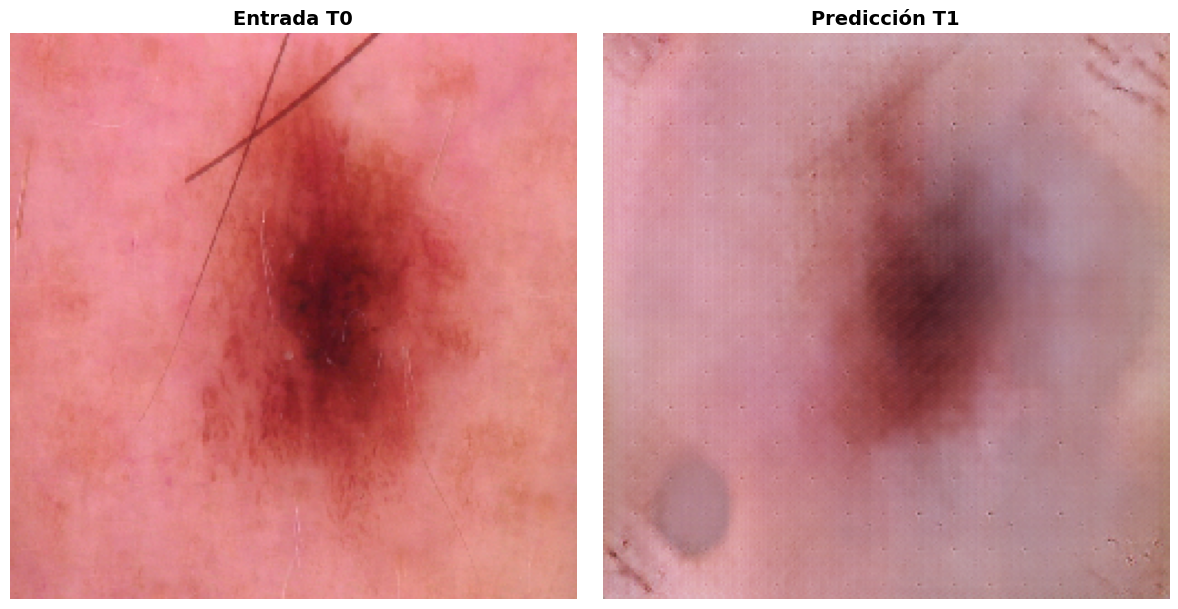

Resultado guardado en: Resultados_DenseNet_FT/ISIC_0024306_prediccion.png


array([[[0.73119074, 0.5569524 , 0.5482403 ],
        [0.79861486, 0.5660968 , 0.5611421 ],
        [0.8032769 , 0.5716541 , 0.59479606],
        ...,
        [0.79282767, 0.60174376, 0.6144407 ],
        [0.7808145 , 0.59087443, 0.60539436],
        [0.69084924, 0.55476177, 0.53802437]],

       [[0.7666102 , 0.5335651 , 0.5992042 ],
        [0.8362217 , 0.5839718 , 0.5999996 ],
        [0.8472774 , 0.59512204, 0.62022626],
        ...,
        [0.82692724, 0.6217622 , 0.6421931 ],
        [0.80925226, 0.608512  , 0.6184314 ],
        [0.7556339 , 0.5662742 , 0.5378895 ]],

       [[0.8491546 , 0.6680406 , 0.68936133],
        [0.8418243 , 0.5980749 , 0.6341189 ],
        [0.8229606 , 0.6056575 , 0.61121106],
        ...,
        [0.76349914, 0.57776415, 0.58355516],
        [0.7252241 , 0.5423573 , 0.5521783 ],
        [0.8187075 , 0.6338018 , 0.6100774 ]],

       ...,

       [[0.77675486, 0.57930404, 0.608723  ],
        [0.8251327 , 0.5927785 , 0.6389649 ],
        [0.80111593, 0

In [ ]:
# Subirá un diálogo para seleccionar archivo
generar_desde_archivo_subido()

In [ ]:
# Generar predicciones para todas las imágenes de train_A
generar_batch_predicciones('Dataset_Evolutivo_Simulado/train_A')

In [ ]:
# Generar 5 predicciones aleatorias
import random
archivos_test = random.sample(glob.glob('Dataset_Evolutivo_Simulado/train_A/*.jpg'), 5)

for archivo in archivos_test:
    generar_prediccion(archivo, mostrar=True, guardar=True)